
# Week 4 — API Development, Evaluation & Final Delivery

In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn joblib fastapi uvicorn nest-asyncio

# Step-1 Import Libraries 

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print(' All libraries loaded!')

 All libraries loaded!


# Step- 2 Load Dataset

In [16]:
# Load dataset
# Upload processed_grievances.csv to Colab before running this cell
df = pd.read_csv('processed_grievances.csv')

#Rename 'product' column to 'department' for clarity
df = df.rename(columns={'product': 'department'})

# Drop rows with missing processed_text
df = df.dropna(subset=['processed_text'])
df['processed_text'] = df['processed_text'].astype(str)

print(f' Dataset loaded: {df.shape[0]:,} rows')
print(f'Columns: {list(df.columns)}')
print(f'\nDepartment distribution:')
print(df['department'].value_counts())

 Dataset loaded: 162,421 rows
Columns: ['Unnamed: 0', 'department', 'narrative', 'text_length', 'word_count', 'cleaned_text', 'processed_text']

Department distribution:
department
credit_reporting       91179
debt_collection        23150
mortgages_and_loans    18990
credit_card            15566
retail_banking         13536
Name: count, dtype: int64


In [17]:
# Use a stratified sample for faster training (use full data if GPU available)
df_sample = df.groupby('department', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 3000), random_state=42)
).reset_index(drop=True)

print(f' Sampled dataset: {len(df_sample):,} rows')
print(df_sample['department'].value_counts())

 Sampled dataset: 15,000 rows
department
credit_card            3000
credit_reporting       3000
debt_collection        3000
mortgages_and_loans    3000
retail_banking         3000
Name: count, dtype: int64


---
## Step- 3 Add Synthetic Sentiment Labels
> Since the dataset doesn't have sentiment labels, we'll assign them based on urgency keywords — a common real-world NLP technique called rule-based pre-labeling.

Sentiment labels assigned!
sentiment
Negative    5629
Critical    5198
Neutral     3742
Positive     431
Name: count, dtype: int64


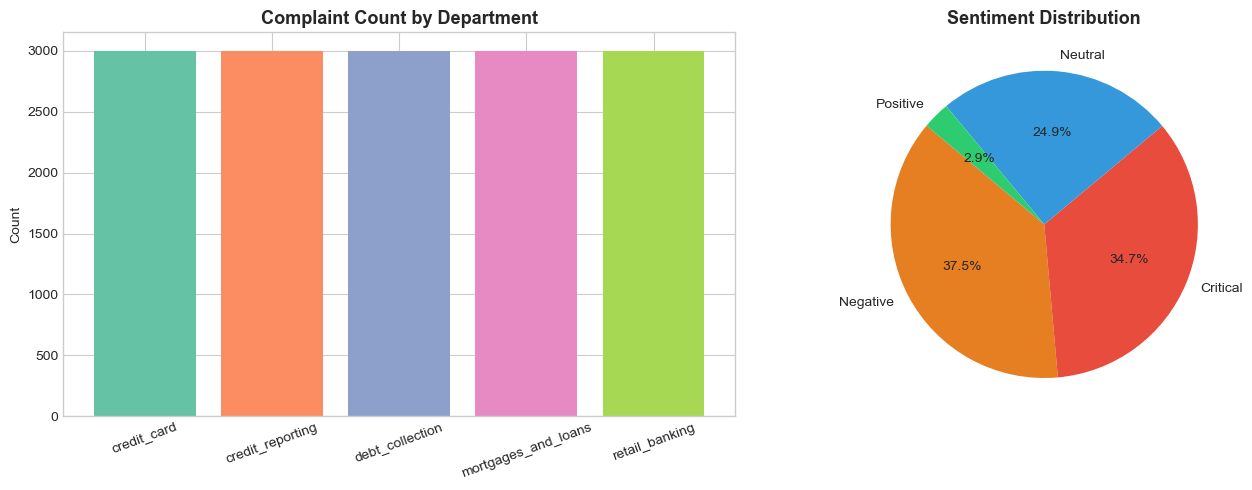

In [18]:
def assign_sentiment(text):
    """Assign sentiment based on urgency keywords in the complaint text."""
    text = str(text).lower()
    
    critical_keywords = [
        'fraud', 'stolen', 'illegal', 'lawsuit', 'attorney', 'court',
        'emergency', 'urgent', 'immediately', 'criminal', 'scam', 'harassment'
    ]
    negative_keywords = [
        'wrong', 'error', 'problem', 'issue', 'complaint', 'denied',
        'unfair', 'incorrect', 'failed', 'refuse', 'never', 'worst',
        'terrible', 'horrible', 'angry', 'frustrated', 'disappoint'
    ]
    positive_keywords = [
        'thank', 'great', 'good', 'excellent', 'resolved', 'happy',
        'satisfied', 'appreciate', 'helpful', 'perfect', 'wonderful'
    ]
    
    if any(word in text for word in critical_keywords):
        return 'Critical'
    elif any(word in text for word in negative_keywords):
        return 'Negative'
    elif any(word in text for word in positive_keywords):
        return 'Positive'
    else:
        return 'Neutral'

df_sample['sentiment'] = df_sample['narrative'].apply(assign_sentiment)

print('Sentiment labels assigned!')
print(df_sample['sentiment'].value_counts())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dept_counts = df_sample['department'].value_counts()
axes[0].bar(dept_counts.index, dept_counts.values, color=sns.color_palette('Set2'))
axes[0].set_title('Complaint Count by Department', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylabel('Count')

sent_counts = df_sample['sentiment'].value_counts()
colors = {'Critical': '#e74c3c', 'Negative': '#e67e22', 'Neutral': '#3498db', 'Positive': '#2ecc71'}
axes[1].pie(
    sent_counts.values,
    labels=sent_counts.index,
    autopct='%1.1f%%',
    colors=[colors.get(s, 'grey') for s in sent_counts.index],
    startangle=140
)
axes[1].set_title('Sentiment Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Step- 4 Train-Test-Split

In [20]:
X = df_sample['processed_text']
y_dept = df_sample['department']
y_sent = df_sample['sentiment']

# Split for department classifier
X_train, X_test, y_dept_train, y_dept_test = train_test_split(
    X, y_dept, test_size=0.2, random_state=42, stratify=y_dept
)

# Split for sentiment classifier (same indices)
_, _, y_sent_train, y_sent_test = train_test_split(
    X, y_sent, test_size=0.2, random_state=42, stratify=y_sent
)

print(f' Train set: {len(X_train):,} samples')
print(f' Test set:  {len(X_test):,} samples')

 Train set: 12,000 samples
 Test set:  3,000 samples
